# Tutorial 2: Block-Based Architecture Discovery on Fashion-MNIST

This tutorial introduces block-based architecture search, where models are assembled from
heterogeneous building blocks — Conv, MLP, and ConvAttn (attention) — rather than a fixed
topology. Because `use_hardware_metrics` is set to `False` here, rule4ml is not invoked,
which means the full block type vocabulary (including `ConvAttn`) is available. This makes
the search space more diverse and better suited for exploring architectural variety without
the constraint of FPGA synthesizability estimates. Hardware-aware search (enabling rule4ml
and restricting to supported layer types) is covered in a later tutorial.

Uses combined QAT + pruning local search. All parameters are controlled via `t2_config.yaml`.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import yaml
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_local_search_combined import combined_local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_fashion_mnist

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

cfg = yaml.safe_load(open(Path.cwd() / "t2_config.yaml"))
ds_cfg = cfg["dataset"]
s_cfg = cfg["search"]
ss_cfg = cfg["search_space"]
ls_cfg = cfg["local_search"]
out_cfg = cfg["output"]

RESULTS_DIR = out_cfg["results_dir"]
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results dir: {RESULTS_DIR}")

2026-02-24 14:48:37.424574: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.15.1
Results dir: ./results/tutorial2_block_attention


## Dataset: Fashion-MNIST

Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000,), y_val shape: (10000,)


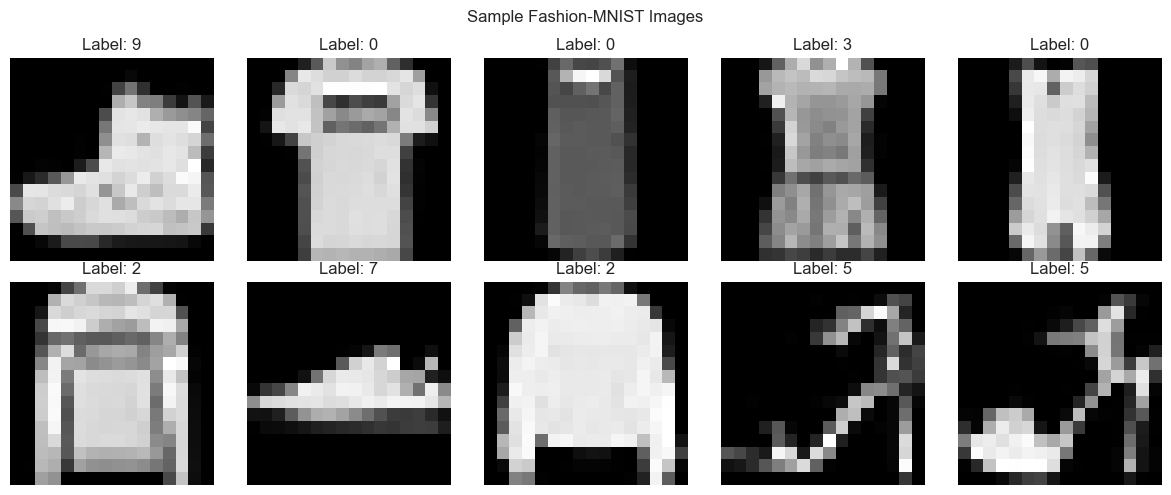

In [2]:
x_train_viz, y_train_viz, _, _ = load_and_preprocess_fashion_mnist(
    resize_val=ds_cfg["resize_val"],
    subset_size=ds_cfg["subset_size"],
    flatten=False,
    one_hot=False,
)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

## Global Search: Building with Blocks

Runs NSGA-II multi-objective search optimizing accuracy and BOPs. Because hardware metrics
are disabled, the sampler can freely mix Conv, MLP, and ConvAttn blocks — giving it broader
coverage of the architecture space than a hardware-constrained search would allow.

Optional k-fold cross-validation (`n_folds > 1`) reduces sensitivity to random initialization.

In [3]:
obj_names = s_cfg["objective_names"]
max_flags = s_cfg["maximize_flags"]
n_folds = s_cfg.get("n_folds", 1)

searcher = GlobalSearchTF(
    search_space_path=ss_cfg,
    results_dir=RESULTS_DIR,
)

study = searcher.run_search(
    model_type=s_cfg["model_type"],
    n_trials=s_cfg["n_trials"],
    epochs=s_cfg["epochs"],
    dataset=ds_cfg["name"],
    subset_size=ds_cfg["subset_size"],
    resize_val=ds_cfg["resize_val"],
    objectives=obj_names,
    maximize_flags=max_flags,
    use_hardware_metrics=s_cfg["use_hardware_metrics"],
    one_hot=ds_cfg["one_hot"],
    n_folds=n_folds,
)

print("Global Search Complete!")


Starting BLOCK Global Search on FASHION_MNIST



[I 2026-02-24 14:48:42,018] A new study created in memory with name: no-name-7bebed29-79c3-4e92-9bd4-d7243c54dbf9


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)
Using in-memory Optuna study (single-node mode)


[I 2026-02-24 14:48:59,356] Trial 0 finished with values: [0.8167676528294882, 2850816.0] and parameters: {'b0': 'ConvAttn', 'b1': 'None', 'b2': 'ConvAttn', 'b3': 'MLP', 'b3_MLP_units': 0, 'b3_MLP_act': 'GELU', 'b3_MLP_norm': None, 'MLP_Head_width_0': 3, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 0: Folds=[0.8107, 0.8234, 0.8162], MeanAcc=0.8168, BOPs=2850816


...

Trial 12: Folds=[0.8347, 0.8361, 0.8483], MeanAcc=0.8397, BOPs=5357568


[I 2026-02-24 15:26:12,331] Trial 13 finished with values: [0.85496852795283, 29966336.0] and parameters: {'b0': 'ConvAttn', 'b1': 'ConvAttn', 'b2': 'Conv', 'b3': 'Conv', 'b2_Conv_channels_0': 0, 'b2_Conv_channels_1': 0, 'b2_Conv_kernels_0': 3, 'b2_Conv_kernels_1': 3, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'GELU', 'b2_Conv_norms_0': None, 'b2_Conv_norms_1': 'batch', 'b3_Conv_channels_0': 2, 'b3_Conv_channels_1': 2, 'b3_Conv_kernels_0': 5, 'b3_Conv_kernels_1': 3, 'b3_Conv_acts_0': 'ReLU', 'b3_Conv_acts_1': 'LeakyRelu', 'b3_Conv_norms_0': None, 'b3_Conv_norms_1': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 2, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 13: Folds=[0.8464, 0.8573, 0.8613], MeanAcc=0.8550, BOPs=29966336


[I 2026-02-24 15:26:31,998] Trial 14 finished with values: [0.8249009052912394, 5226496.0] and parameters: {'b0': 'ConvAttn', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'MLP', 'b1_MLP_units': 0, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'b2_MLP_units': 1, 'b2_MLP_act': 'GELU', 'b2_MLP_norm': None, 'b3_MLP_units': 3, 'b3_MLP_act': 'LeakyRelu', 'b3_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}.


Trial 14: Folds=[0.8202, 0.8280, 0.8265], MeanAcc=0.8249, BOPs=5226496

CSV results saved to ./results/tutorial2_block_attention/block_search_results.csv (15 trials)

🏆 Best model architecture (Trial 8) saved for local search:
   - Source: ./results/tutorial2_block_attention/trial_yamls/trial_8_arch.yaml
   - Destination: ./results/tutorial2_block_attention/best_model_for_local_search.yaml
   - Accuracy: 0.8679
2D Pareto fronts plot saved to ./results/tutorial2_block_attention/pareto_fronts_2d.png

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.8167676528294882, 'bops': 2850816.0}
  Params: {'b0': 'ConvAttn', 'b1': 'None', 'b2': 'ConvAttn', 'b3': 'MLP', 'b3_MLP_units': 0, 'b3_MLP_act': 'GELU', 'b3_MLP_norm': None, 'MLP_Head_width_0': 3, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}

Rank 2 (Trial 5):
  Values:

## Analyzing the Global Search Results

In [4]:
results_df = pd.DataFrame(searcher.results)
if not results_df.empty:
    best = results_df.loc[results_df['performance_metric'].idxmax()]
    print(f"Best Trial: {best['trial']}  Accuracy: {best['performance_metric']:.4f}  BOPs: {best['bops']:.2e}")
    print(f"Pareto front plots saved to: {RESULTS_DIR}")
else:
    print("No results to visualize.")

Best Trial: 8  Accuracy: 0.8679  BOPs: 3.34e+07
Pareto front plots saved to: ./results/tutorial2_block_attention


## Local Search: Combined QAT + Pruning

Applies iterative magnitude pruning to each quantized model, revealing the full compression landscape.

In [5]:
LOCAL_RESULTS_DIR = os.path.join(RESULTS_DIR, "local_search_combined")
LOCAL_CONFIG_PATH = os.path.join(RESULTS_DIR, "local_search_config.yaml")
ARCH_YAML_PATH = os.path.join(RESULTS_DIR, "best_model_for_local_search.yaml")

local_search_settings = {
    "pruning_settings": {
        "iterations": ls_cfg["pruning_iterations"],
        "epochs_per_iteration": ls_cfg["pruning_epochs"],
        "pruning_rate": ls_cfg["pruning_rate"],
    },
    "qat_settings": {
        "epochs": ls_cfg["qat_epochs"],
        "precision_pairs": ls_cfg["precision_pairs"],
    },
}
with open(LOCAL_CONFIG_PATH, "w") as f:
    yaml.dump(local_search_settings, f)

x_train, y_train, x_val, y_val = load_and_preprocess_fashion_mnist(
    resize_val=ds_cfg["resize_val"],
    subset_size=ds_cfg["subset_size"],
    flatten=False,
    one_hot=True,
)

if not os.path.exists(ARCH_YAML_PATH):
    raise FileNotFoundError(f"Could not find best architecture YAML: {ARCH_YAML_PATH}. Run global search first.")

combined_df = combined_local_search_entrypoint(
    architecture_yaml_path=ARCH_YAML_PATH,
    local_search_config_path=LOCAL_CONFIG_PATH,
    dataset=(x_train, y_train, x_val, y_val),
    results_dir=LOCAL_RESULTS_DIR,
    n_folds=n_folds,
)

Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (20000, 16, 16, 1), x_val shape: (10000, 16, 16, 1)
  y_train shape: (20000, 10), y_val shape: (10000, 10)

 STARTING COMBINED QAT+PRUNING LOCAL SEARCH (k-fold CV, 3 folds) 
Baseline FP32 BOPs: 1.04e+07

==================== Precision: <16,6> ====================
  Fold 1/3: QAT warmup... acc=0.8397
  Fold 2/3: QAT warmup... acc=0.8557
  Fold 3/3: QAT warmup... acc=0.8500
  Iter  0 (baseline): acc=0.8484 (3 folds)  eff_bops=2.60e+06
  Iter  1/10: acc=0.8501 (3 folds)  sparsity=0.2987  eff_bops=1.82e+06 *
  Iter  2/10: acc=0.8502 (3 folds)  sparsity=0.5077  eff_bops=1.28e+06 *
  Iter  3/10: acc=0.8519 (3 folds)  sparsity=0.6540  eff_bops=8.99e+05 *
  Iter  4/10: acc=0.8343 (3 folds)  sparsity=0.7564  eff_bops=6.33e+05
  Iter  5/10: acc=0.8179 (3 folds)  sparsity=0.8281  eff_bops=4.46e+05
  Iter  6/10: acc=0.7042 (3 folds)  sparsity=0.8783  eff_bops=3.16e+05
  Iter  7/10: acc=0.5820 (3 folds)  sparsity=0.9135  eff_bops=2.25e+

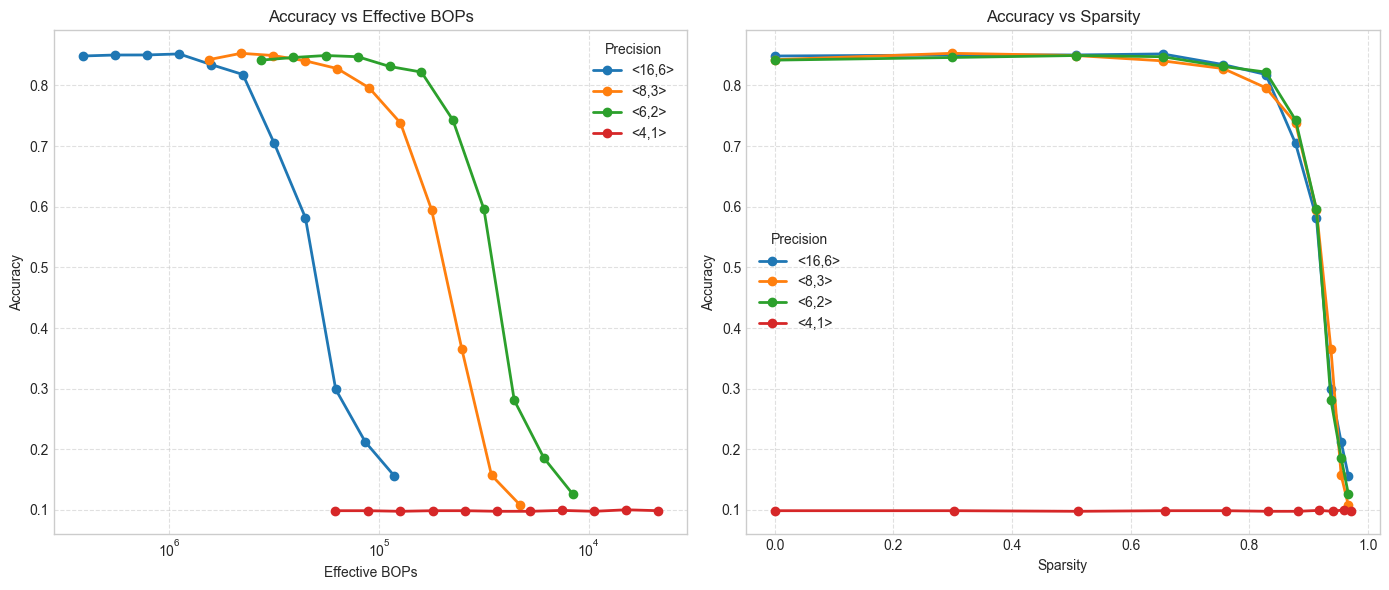

In [6]:
if isinstance(combined_df, pd.DataFrame) and not combined_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for prec in combined_df["Precision"].unique():
        sub = combined_df[combined_df["Precision"] == prec]
        axes[0].plot(sub["EffectiveBOPs"], sub["Accuracy"], marker="o", linewidth=2, label=prec)
        axes[1].plot(sub["Sparsity"], sub["Accuracy"], marker="o", linewidth=2, label=prec)
    axes[0].set(xlabel="Effective BOPs", ylabel="Accuracy", title="Accuracy vs Effective BOPs")
    axes[0].set_xscale("log")
    axes[0].invert_xaxis()
    axes[0].legend(title="Precision")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[1].set(xlabel="Sparsity", ylabel="Accuracy", title="Accuracy vs Sparsity")
    axes[1].legend(title="Precision")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No combined local search results to plot.")